## 1.Familiarize with data

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import numpy as np

data: pd.DataFrame = pd.read_csv("train.csv")
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


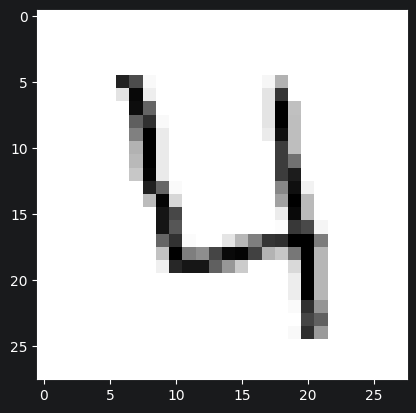

In [2]:
X = data.drop(columns=["label"])
y = data["label"]

example_of_digit_4 = X.iloc[3]
image_of_digit_4 = example_of_digit_4.values.reshape(28, 28)
plt.imshow(image_of_digit_4, cmap="binary")

## 2. Spliting data

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(33600, 784)
(8400, 784)


## 3. SGD (Stochastic Gradient Descent) and Cross validation

In [4]:
SGD_clf = SGDClassifier(random_state=42)
cross_validation = cross_val_score(SGD_clf, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1)
print(f"Accuracy: {cross_validation}")
print(f"Mean Accuracy: {cross_validation.mean()}")

Accuracy: [0.88258929 0.86910714 0.8725    ]
Mean Accuracy: 0.8747321428571428


## 4. Confusion Matrix

In [5]:
y_predicted = cross_val_predict(SGD_clf, X_train, y_train, cv=3, n_jobs=-1)
confusion_mtx = confusion_matrix(y_train, y_predicted)
print(confusion_mtx)

[[3095    0   35   36    7   19   49   10   57    8]
 [   0 3532   33   22    8   14    9    5  142   10]
 [  13   38 2826  109   43   15   57   45  165   20]
 [   6   14   95 2991   13   80   31   35  108   41]
 [   5   17   41   17 2909    7   39   12   62  124]
 [  40    9   27  227   47 2255  117   13  286   72]
 [  16    5   62    9   23   39 3152    3   42    1]
 [  12   12   43   60   43    8    7 3095   39  189]
 [  19   40   48  172   35   77   32   10 2741   54]
 [  10   11   15   85  159   35    4  136  100 2795]]


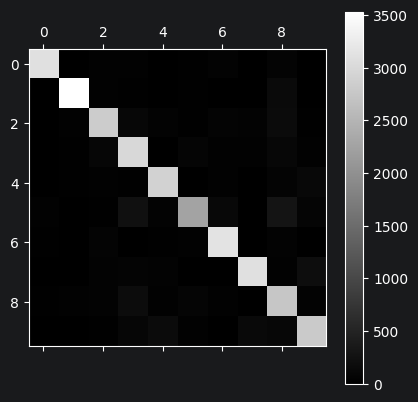

In [6]:
plt.matshow(confusion_mtx, cmap="grey")
plt.colorbar()

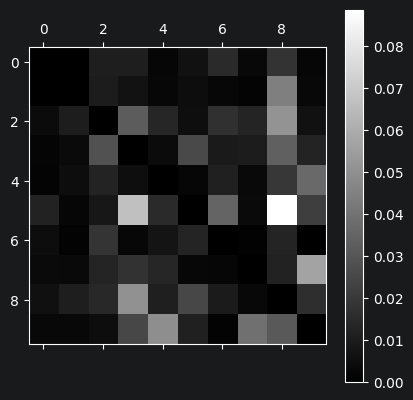

In [7]:
row_sums = np.sum(confusion_mtx, axis=1)
norm_conf_mtx = confusion_mtx / row_sums
np.fill_diagonal(norm_conf_mtx, 0)

plt.matshow(norm_conf_mtx, cmap="grey")
plt.colorbar()

In [8]:
false_with_5_and_8 = (y_train == 5) & (y_predicted == 8)
false_5 = X_train[false_with_5_and_8]
print(len(false_5))

286


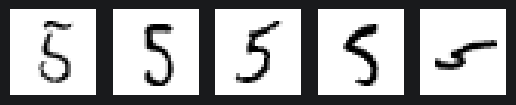

In [9]:
for i in range(5):
    image = false_5.iloc[i].values.reshape(28, 28)
    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap="gray")
    plt.imshow(image, cmap="binary")
    plt.axis('off')

## 5. Finally model

In [10]:
test_data = pd.read_csv("test.csv")

SGD_clf.fit(X_train, y_train)
predicted = SGD_clf.predict(test_data)

submission = pd.DataFrame({
    "ImageId": range(1, 28001),
    "Label": predicted,
})

submission.to_csv("submission.csv", index=False)